In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision

import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
transform = transforms.Compose([
  transforms.Resize((128, 128)),
  transforms.ToTensor(),
  transforms.Normalize((0.5,), (0.5,)) 
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size=512
epochs=100
n_workers=4

In [3]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=n_workers) 

In [4]:
class Blender(nn.Module):
  def __init__(self, dim):
    super().__init__()
    self.dim=dim
    self.conv_down_stack = nn.Sequential(
      nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
      nn.MaxPool2d(2, 2), # B,32,64,64
      nn.ReLU(),
      nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
      nn.MaxPool2d(2, 2), #B,64,32,32
      nn.ReLU(),
      nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
      nn.MaxPool2d(2, 2), #B,128,16,16
      nn.ReLU(),
    )
    self.fc = nn.Linear(128*16*16, dim)
    
    self.prompt_embed = nn.Embedding(10, dim)
    
    self.image_q = nn.Linear(dim, dim)
    self.image_v = nn.Linear(dim, dim)
    self.image_k = nn.Linear(dim, dim)
    
    self.prompt_q = nn.Linear(dim, dim)
    self.prompt_v = nn.Linear(dim, dim)
    self.prompt_k = nn.Linear(dim, dim)
    
    self.conv_up_stack = nn.Sequential(
      nn.ConvTranspose2d(dim//2, 128, kernel_size=3, stride=2, padding=1, output_padding=1), #B,128,32,32
      nn.ReLU(),
      nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), #B,64,64,64
      nn.ReLU(),
      nn.ConvTranspose2d(64, 1, kernel_size=3, stride=2, padding=1, output_padding=1), #B,1,128,128
      nn.Tanh()
    ) 

    self.image_fc = nn.Linear(dim,dim)
    self.image_up_fc = nn.Linear(dim,128*16*16)

    self.timestep_fc = nn.Linear(dim, dim)
  def timestep_embedding(self, t):
    # Create a sinusoidal embedding for the time step
    half_dim = self.dim // 2
    emb = torch.exp(torch.arange(half_dim, device=t.device) * -(torch.log(torch.tensor(10000.0)) / half_dim))
    emb = t[:, None] * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    emb = emb.reshape(emb.size(0),-1)
    #print(f"emb shape: {emb.shape}")
    return self.timestep_fc(emb)
  def forward(self, prompt, image, timestep):
    image_down = self.conv_down_stack(image) #B,128,16,16
    #print(f"image down size: {image_down.size()}")
    image_shape = image_down.size()
    image_flat = image_down.view(image_down.size(0), -1) #B,
    #print(f"size: {image_flat.size()}")

    image_emb = self.fc(image_flat) #B,dim
    prompt_emb = self.prompt_embed(prompt) #B,dim
    timestep_emb = self.timestep_embedding(timestep) #B,dim

    image_emb = image_emb + timestep_emb
    prompt_emb = prompt_emb + timestep_emb
    
    image_q = self.image_q(image_emb) #B,dim
    image_k = self.image_k(image_emb) #B,dim
    image_v = self.image_v(image_emb) #B,dim
    
    prompt_q = self.prompt_q(prompt_emb) #B,dim
    prompt_k = self.prompt_k(prompt_emb) #B,dim
    prompt_v = self.prompt_v(prompt_emb) #B,dim
    
    Q = torch.stack([image_q, prompt_q], dim=1) #B,2,dim
    K = torch.stack([image_k, prompt_k], dim=1) #B,2,dim
    V = torch.stack([image_v, prompt_v], dim=1) #B,2,dim
    
    out = F.scaled_dot_product_attention(Q, K, V) #B,2,dim
    # prompt_attn = out[:, 1:, :] #B,1,dim
    # print(f"shape after transformer: {out[:,1:,:].squeeze(1).shape}")
    img_attn = self.image_fc(out[:,1:,:].squeeze(1)) #B,dim
    # img_attn= self.image_fc(out) #B,dim
    #print(img_attn.shape)
    # img_attn = out[:, :1, :] #B,1,dim
    

    img_attn = img_attn.squeeze(1) #B,dim
    img_attn = self.image_up_fc(img_attn) #B,128*16*16
    img_attn = img_attn.view(image_shape) #B,128,16,16
    #print(f"image attn shape before conv up stack {img_attn.shape}")
    out = self.conv_up_stack(img_attn) #B,1,128,128
    
    return out

In [5]:
model= Blender(dim=256).to(torch.float32)
prompt = torch.zeros((1,), dtype=torch.long)          # <-- batch of 1 token id (all zeros)
image  = torch.randn((1, 1, 128, 128), dtype=torch.float32)  # add channel dim
timestep = torch.randn((1, 1), dtype=torch.float32)
out = model(prompt, image, timestep)

In [ ]:
model = model.to(device)
torch.set_float32_matmul_precision("high")
compiled_model = torch.compile(model)
optimizer = optim.Adam(lr=1e-3, params=model.parameters())

pbar = tqdm(total=len(dataloader) * epochs)

for epoch in range(epochs):
    for count, (image, prompt) in enumerate(dataloader):
        image = image.to(device)
        prompt = prompt.to(device)

        t = torch.rand((image.size(0), 1)).to(device)
        x1 = image
        x0 = torch.randn_like(image)

        t_broadcast = t.unsqueeze(-1).unsqueeze(-1)
        x_t = x0 * (1 - t_broadcast) + x1 * t_broadcast

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
          v_predicted = compiled_model(prompt, x_t, t)
          v_target = x1 - x0

          loss = F.mse_loss(v_predicted, v_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pbar.update(1)
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "epoch": epoch})

pbar.close()

  6%|▌         | 732/11800 [00:52<13:15, 13.91it/s, loss=1.0305, epoch=6]

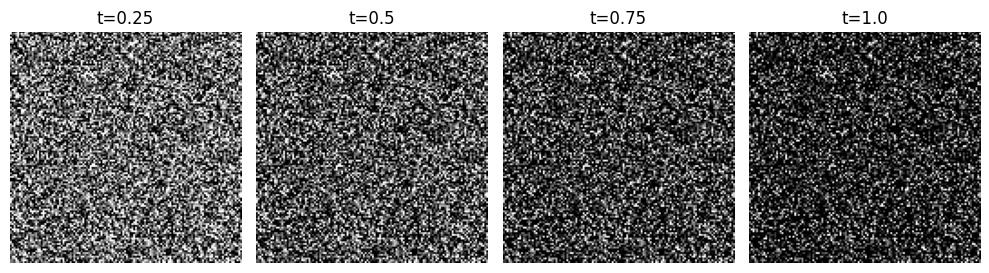

In [ ]:
# === Inference Cell ===

import torch
import matplotlib.pyplot as plt

model.eval()

# choose a digit (0–9)
digit = 7
prompt = torch.tensor([digit], device=device, dtype=torch.long)

# start from pure noise (t=0)
x = torch.randn(1, 1, 128, 128, device=device)

num_steps = 100
dt = 1.0 / num_steps

snapshots = {}
target_times = [0.25, 0.5, 0.75, 1.0]

with torch.no_grad():
    for step in range(num_steps):
        t = torch.full((1, 1), step / num_steps, device=device)

        v = model(prompt, x, t)  # predicted velocity (x1 - x0)

        # Euler integration: x_{t+dt} = x_t + v * dt
        x = x + v * dt

        current_time = (step + 1) / num_steps

        for target in target_times:
            if target not in snapshots and current_time >= target:
                snapshots[target] = x.detach().cpu()

# Plot results
plt.figure(figsize=(10, 3))

for i, t_val in enumerate(target_times):
    img = snapshots[t_val][0, 0]
    img = (img * 0.5 + 0.5).clamp(0, 1)  # unnormalize

    plt.subplot(1, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"t={t_val}")
    plt.axis("off")

plt.tight_layout()
plt.show()